# Reproject spike: `sat_sim` fed by the real WAC crop instead of the Lunaserv basemap

`crop` (the real, ISIS-processed WAC image) and `hillshade` (a synthetic `sat_sim` render, textured
from Lunaserv/Astropedia + a synthetic Hapke hillshade) are the two implemented `TrnTestImage`
types. `reproject` is the reserved-but-unbuilt third one: still a
`sat_sim` render through the *same* synthetic camera as `hillshade` -- so the two are directly,
pixel-for-pixel comparable -- but textured from the real WAC crop's own reflectance instead of a
synthetic basemap. The open question before building the real `TrnTestReprojectImage` class: does
the real crop's own footprint (after `cam2map` reprojection) actually cover the synthetic camera's
FOV out to its corners, or does `sat_sim` hit real gaps there? Testing on one real image first,
before deciding whether the synthetic FOV needs to shrink.

Reuses the same entry (`M1327210646CE`) `image_generation.ipynb`'s own `trn_dataset` folder
already has `crop`+`hillshade` generated for -- `entry.crop_result`/`entry.dem_ortho_result`/
`entry.camera` all resume from already-cached state, not a fresh fetch.

In [1]:
import dataclasses

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spiceypy as spice

import trntest
from trntest import camera as camera_module
from trntest import isis_wac, lunaserv, plotting, render
from trntest.config import MOON_RADIUS_KM

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
# NOT dataset.populate(limit=1) -- entry 0 already has crop+hillshade generated (from
# image_generation.ipynb's own prior run); populate(limit=1) would silently move on to the next
# *undone* entry instead and do real, unwanted work there (confirmed live -- see docs/history.md).
entry = dataset[0]

## Reproject the real WAC crop onto the basemap's own CRS

The same call `TrnTestCropImage._mapprojected_path()` makes internally for the overlay comparison
-- `DEFAULTRANGE=camera` auto-sizes the output to the crop's own real footprint, not padded, which
is exactly the coverage risk being tested here.

In [2]:
wac_ortho_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
print("Real WAC crop, reprojected:", wac_ortho_path)

Real WAC crop, reprojected: /workspace/scratch/isis_wac/M1327210646CE/M1327210646CE.vis.cal.stitched.crop-cam2map.tif


## Wrap it as a `DemOrthoResult` and render through the same camera as `hillshade`

`lunaserv.result_from_files` reads `bbox`/`width`/`height` back from `wac_ortho_path`'s own
georeferencing -- reusing `entry.dem_ortho_result.dem` (the same DEM tile `hillshade` used) as the
elevation source, only the imagery source changes. `entry.camera` is the same cached `Camera`
instance `hillshade` itself renders with -- byte-identical pose/FOV/intrinsics, not just
equivalent ones.

In [3]:
reproject_dem_ortho = lunaserv.result_from_files(wac_ortho_path, entry.dem_ortho_result.dem)
reproject_render = render.run_sat_sim(entry.camera, reproject_dem_ortho, entry.per_image_config)
print("Reproject render:", reproject_render.rendered_tif)

Reproject render: /workspace/output/trn_dataset/_work/M1327210646CE/render/run-camera_frame94.tif


## Coverage check: any real gaps at the synthetic FOV's edges/corners?

In [4]:
data = plotting.read_raster_band(reproject_render.rendered_tif)
valid = plotting.valid_pixel_mask(data)
print(f"Valid pixels: {valid.mean():.1%}")

edge_px = max(1, data.shape[0] // 20)  # outer ~5% ring
ring_mask = np.zeros_like(valid)
ring_mask[:edge_px, :] = ring_mask[-edge_px:, :] = True
ring_mask[:, :edge_px] = ring_mask[:, -edge_px:] = True
print(f"Valid pixels in the outer ~5% edge ring: {valid[ring_mask].mean():.1%}")

corner = edge_px * 2
for name, sl in [
    ("top-left", (slice(0, corner), slice(0, corner))),
    ("top-right", (slice(0, corner), slice(-corner, None))),
    ("bottom-left", (slice(-corner, None), slice(0, corner))),
    ("bottom-right", (slice(-corner, None), slice(-corner, None))),
]:
    print(f"  {name} corner valid: {valid[sl].mean():.1%}")

Valid pixels: 100.0%
Valid pixels in the outer ~5% edge ring: 100.0%
  top-left corner valid: 100.0%
  top-right corner valid: 100.0%
  bottom-left corner valid: 100.0%
  bottom-right corner valid: 100.0%


Per-row/per-column valid-fraction profile -- direct-observation follow-up (user noticed the whole
bottom row is nodata, top looks "thicker") to check the actual shape of the gap: a clean linear
taper (consistent with an axis-aligned box bounding a skewed pushframe footprint, tapering to zero
at one edge) vs. something sharper/more irregular.

Row 0 (top) valid: 100.0%, row -1 (bottom) valid: 100.0%
First fully-empty row (from top): None of 256


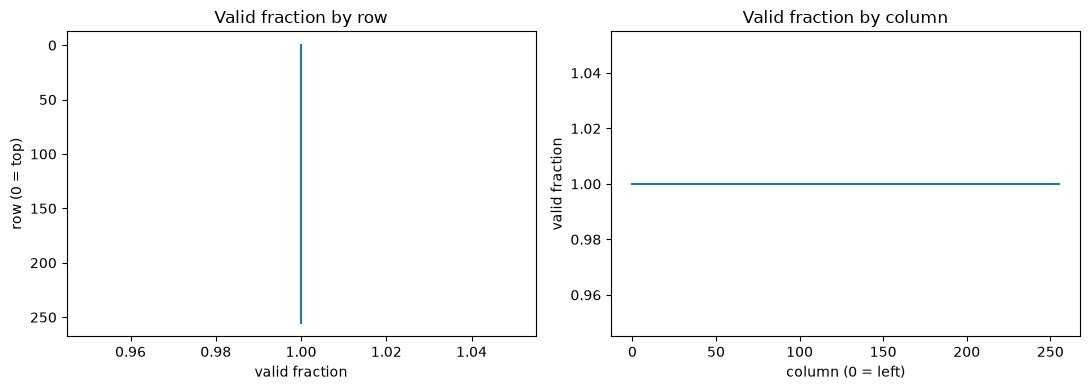

In [5]:
row_valid_frac = valid.mean(axis=1)
col_valid_frac = valid.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(row_valid_frac, np.arange(len(row_valid_frac)))
axes[0].invert_yaxis()
axes[0].set_xlabel("valid fraction")
axes[0].set_ylabel("row (0 = top)")
axes[0].set_title("Valid fraction by row")
axes[1].plot(col_valid_frac)
axes[1].set_xlabel("column (0 = left)")
axes[1].set_ylabel("valid fraction")
axes[1].set_title("Valid fraction by column")
fig.tight_layout()

print(f"Row 0 (top) valid: {row_valid_frac[0]:.1%}, row -1 (bottom) valid: {row_valid_frac[-1]:.1%}")
first_fully_empty_row = np.argmax(row_valid_frac == 0.0) if (row_valid_frac == 0.0).any() else None
print(f"First fully-empty row (from top): {first_fully_empty_row} of {len(row_valid_frac)}")

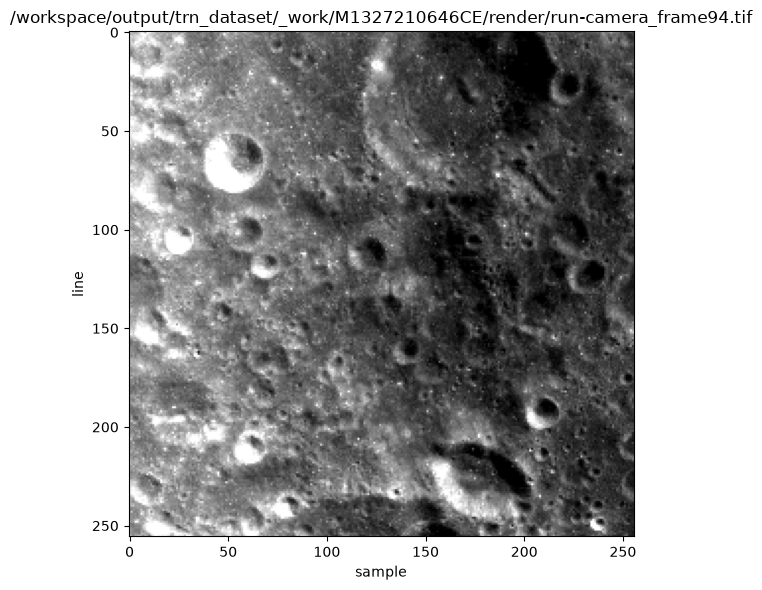

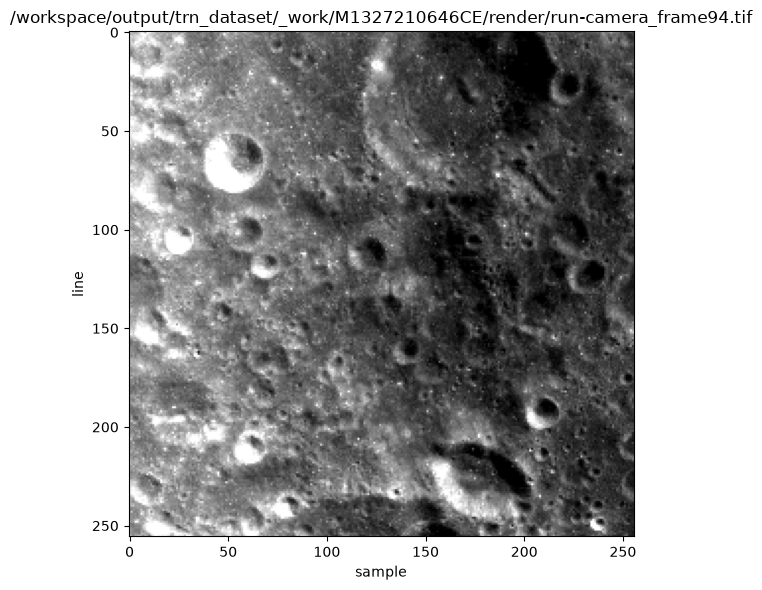

In [6]:
plotting.plot_raster(reproject_render.rendered_tif, cmap="gray")

For comparison, `hillshade`'s own render through the same camera:

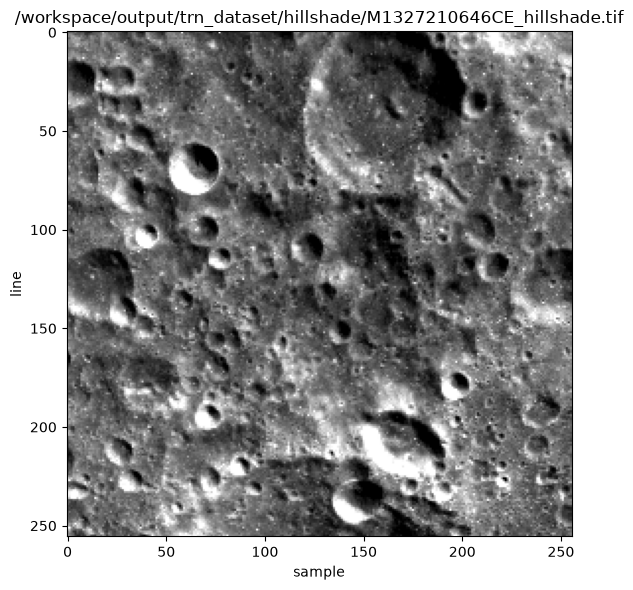

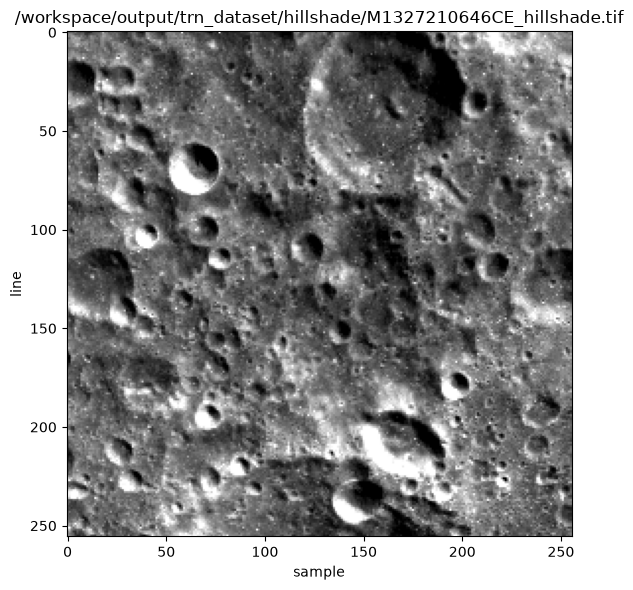

In [7]:
plotting.plot_raster(entry.hillshade.raster_path, cmap="gray")

## Root cause: does the *raw* crop cube itself already lack data at that edge?

Three candidate explanations for the bottom-edge gap: (1) the crop window itself
(`isis_wac.crop_window_for_camera`, `n_frames_for_square_crop` lines centered on
`center_frame_index`) runs off the end of the real acquisition/stitched cube, so the raw crop
already has missing DN data there; (2) the crop window is fully populated, but the real ground
footprint it covers is a skewed quadrilateral (pushframe along-track motion) that a
`cam2map`/`DEFAULTRANGE=camera` axis-aligned bounding box can't fully contain, so cam2map's own
reprojection introduces the gap even though the source data is complete; (3) something specific
to `cam2map`'s own warp/patch behavior (`docs/plan.md`'s cam2map striping/warp-patch history).

Checking (1) first, directly on the raw crop cube, before cam2map ever runs.

Raw crop cube shape: (980, 704) (line, sample)
Raw crop overall valid: 99.0%
Raw crop line 0 (start) valid: 92.0%, line -1 (end) valid: 99.6%
Raw crop min line valid fraction: 92.0% at line 0


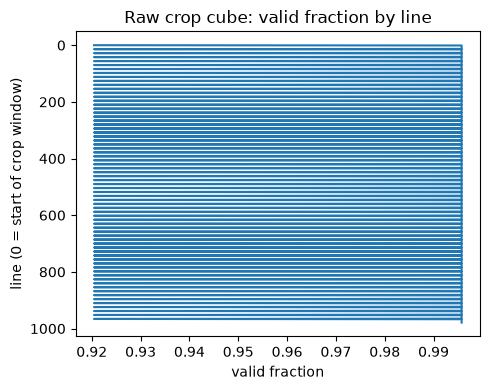

In [8]:
raw_crop_data = plotting.read_raster_band(entry.crop_result.cub_path)
raw_crop_valid = plotting.valid_pixel_mask(raw_crop_data)
print(f"Raw crop cube shape: {raw_crop_data.shape} (line, sample)")
print(f"Raw crop overall valid: {raw_crop_valid.mean():.1%}")

raw_row_valid_frac = raw_crop_valid.mean(axis=1)
print(f"Raw crop line 0 (start) valid: {raw_row_valid_frac[0]:.1%}, line -1 (end) valid: {raw_row_valid_frac[-1]:.1%}")
print(f"Raw crop min line valid fraction: {raw_row_valid_frac.min():.1%} at line {raw_row_valid_frac.argmin()}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(raw_row_valid_frac, np.arange(len(raw_row_valid_frac)))
ax.invert_yaxis()
ax.set_xlabel("valid fraction")
ax.set_ylabel("line (0 = start of crop window)")
ax.set_title("Raw crop cube: valid fraction by line")
fig.tight_layout()

## Footprint shape comparison: crop's real footprint vs. the synthetic camera's FOV

Both already computed (`entry.crop_footprint` via real ISIS `campt`, `entry.camera.
footprint_lonlat_deg` via SPICE ray-trace) -- projected into the same local-meters frame (centered
on the synthetic camera's own footprint center) so their actual shapes can be compared directly,
independent of either one's own corner-naming convention (the two rasters don't share a rotation
convention with each other -- see `entry.rotations` -- so name-matched corners aren't guaranteed
to be the same physical corner; comparing raw ground shapes sidesteps that).

Synthetic FOV corners (local m): {'top_left': (55882.98224096821, -68890.15853243067), 'top_right': (-66540.77376091281, -58888.20226220079), 'bottom_left': (74712.61990042917, 61392.41590828773), 'bottom_right': (-63790.73749860807, 72986.45311229424)}
Crop's real footprint corners (local m): {'top_left': (-64443.9421536534, 78250.79508177783), 'top_right': (76032.69741385474, 66637.9012036012), 'bottom_right': (64417.14017084815, -74590.45120061976), 'bottom_left': (-75055.18954335099, -63083.08824376046)}


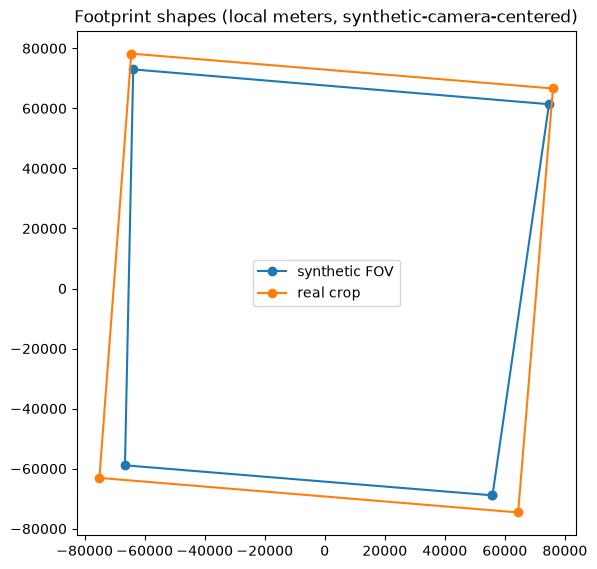

In [9]:
center_lon, center_lat = entry.camera.footprint_lonlat_deg["center"]


def to_local_m(lonlat):
    lon, lat = lonlat
    return lunaserv.orthographic_xy_m(lon, lat, center_lon, center_lat)


synthetic_corners = {k: to_local_m(v) for k, v in entry.camera.footprint_lonlat_deg.items() if k != "center" and v}
crop_corners = {k: to_local_m(v) for k, v in entry.crop_footprint.items() if k != "center" and v}
print("Synthetic FOV corners (local m):", synthetic_corners)
print("Crop's real footprint corners (local m):", crop_corners)


def _polygon_order(corners: dict) -> list:
    order = ["top_left", "top_right", "bottom_right", "bottom_left"]
    return [corners[k] for k in order if k in corners]


fig, ax = plt.subplots(figsize=(6, 6))
for corners, label, color in [
    (synthetic_corners, "synthetic FOV", "tab:blue"),
    (crop_corners, "real crop", "tab:orange"),
]:
    pts = _polygon_order(corners) + [_polygon_order(corners)[0]]
    xs, ys = zip(*pts, strict=True)
    ax.plot(xs, ys, "o-", label=label, color=color)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Footprint shapes (local meters, synthetic-camera-centered)")
fig.tight_layout()

## Root cause, confirmed: two coupled mismatches, not one

`cross_track_width_km` (what `fu` is built from) is a real ray-traced ground chord at this pose's
actual off-nadir geometry. But `n_frames_for_square_crop` (what the real crop's along-track extent
-- and so what `fv` *should* represent) comes from a flat, non-perspective calculation: `n_frames *
km_per_frame`, a simple accumulated ground-track step with no foreshortening in it at all.
`footprint_lonlat` then projects the along-track corners using `fv = fu` -- the same angle, through
the same real (foreshortened) ray-sphere intersection -- so the along-track FOV ends up calibrated
to a flat-distance target but rendered through a perspective model.

Fixing just `fv`/`cv` (tried first, not shown below -- see git history of this file) helps but
doesn't fully close the gap: decomposing each corner into real cross-track/along-track ground
components (via `entry.camera.camera_along_track_direction_moon_me`, the actual camera x-axis for
cross-track) shows the **far corners are also elongated cross-track** (~81-82 km vs. the crop's
own, remarkably constant ~70 km on *both* near and far ends) -- even though `fu`/`cu` never
change. This is a real coupling effect: a corner ray combines the cross-track *and* along-track
angular offsets at once, and the more oblique that combined angle is, the farther out *both* of
its ground components land -- not just the axis you're actively solving for. A standard 4-parameter
pinhole (`fu, fv, cu, cv`) genuinely cannot reproduce this exactly (it has no way to make `fu`
itself depend on `py`), so closing the gap needs `fu` to shrink somewhat too, not just `fv`/`cv`.

Final approach: shrink `fu` by `FU_SCALE`, then solve `fv`/`cv` for the near/far corner rays (not
just the edge midpoint -- an earlier attempt at that barely moved the corners, since a corner's
ground position isn't a simple function of its along-track offset alone) against the real crop's
own near/far corner ground-truth (`entry.crop_footprint`, ISIS `campt`-based), not the flat
`n_frames * km_per_frame` approximation. Both `FU_SCALE` and `AT_MARGIN` deliberately shrink past
an exact fit, per the user's own explicit call: real terrain (vs. this ray-trace's idealized
sphere) will vary the actual coverage some, so a little arbitrary shrinkage traded for reliability
is fine, not something worth solving away.

In [10]:
c_km = np.array(entry.camera.camera_center_moon_me_m) / 1000.0
r_cam_to_me = np.array(entry.camera.r_cam_to_me)
fu_orig = entry.camera.focal_length_u_px
cu = session.config.image_size / 2.0

boresight_ground_km = camera_module.boresight_ground_point_km(c_km, r_cam_to_me)
along_track_axis_me = np.array(entry.camera.camera_along_track_direction_moon_me)
cross_track_axis_me = r_cam_to_me[:, 0]  # camera's own x-axis in MOON_ME -- the real cross-track ground direction


def decompose_km(ground_km: np.ndarray) -> tuple[float, float]:
    rel = ground_km - boresight_ground_km
    return float(np.dot(rel, cross_track_axis_me)), float(np.dot(rel, along_track_axis_me))


crop_ct_km, crop_at_km = {}, {}
for name, lonlat in entry.crop_footprint.items():
    if name == "center" or lonlat is None:
        continue
    lon, lat = lonlat
    ground_km = np.array(spice.latrec(MOON_RADIUS_KM, np.radians(lon), np.radians(lat)))
    crop_ct_km[name], crop_at_km[name] = decompose_km(ground_km)
print("Crop corners (cross-track km, along-track km):")
for name, cross_km in crop_ct_km.items():
    print(f"  {name}: cross={cross_km:.2f}, along={crop_at_km[name]:.2f}")

target_near_km = -np.mean([v for v in crop_at_km.values() if v < 0])
target_far_km = np.mean([v for v in crop_at_km.values() if v >= 0])
print(f"Target near (along-track): {target_near_km:.2f} km, target far: {target_far_km:.2f} km")

Crop corners (cross-track km, along-track km):
  top_left: cross=70.65, along=71.84
  top_right: cross=-70.31, along=71.84
  bottom_right: cross=-70.33, along=-68.89
  bottom_left: cross=69.61, along=-68.90
Target near (along-track): 68.90 km, target far: 71.84 km


In [11]:
def corner_ground_km(half_angle_u: float, half_angle_v: float, sign_u: float, sign_v: float) -> np.ndarray:
    """Real ground point of an image corner ray -- both cross-track and along-track angular offsets
    applied together, matching `camera.pixel_ray_cam`'s own exact ray formula."""
    direction_cam = np.array([sign_u * np.tan(half_angle_u), sign_v * np.tan(half_angle_v), 1.0])
    direction_cam = direction_cam / np.linalg.norm(direction_cam)
    direction_me = r_cam_to_me @ direction_cam
    t = camera_module.ray_sphere_intersect_range(c_km, direction_me)
    assert t is not None, "corner FOV ray does not intersect the Moon"
    return c_km + t * direction_me


def solve_half_angle_v(half_angle_u: float, target_km: float, sign_v: float, hi: float = np.radians(45.0)) -> float:
    """Bisect for the along-track half-angle (radians) whose corner ray (at the given, fixed
    cross-track half-angle) lands its along-track component at `target_km` (a positive magnitude;
    `sign_v` picks near/far) -- monotonic over this range."""
    lo = 1e-4
    for _ in range(60):
        mid = (lo + hi) / 2.0
        _, at = decompose_km(corner_ground_km(half_angle_u, mid, 1.0, sign_v))
        magnitude = sign_v * at
        lo, hi = (mid, hi) if magnitude < target_km else (lo, mid)
    return (lo + hi) / 2.0


FU_SCALE = 0.93  # shrinks the cross-track half-angle -- closes the far-corner cross-track excess
AT_MARGIN = 0.93  # extra shrink on the along-track targets -- real terrain-variation safety margin

original_half_angle_rad = np.radians(session.config.wac_vis_color_fov_deg / 2.0)
half_angle_u = original_half_angle_rad * FU_SCALE
fu_new = (session.config.image_size / 2.0) / np.tan(half_angle_u)

near_half_angle_rad = solve_half_angle_v(half_angle_u, target_near_km * AT_MARGIN, sign_v=-1.0)
far_half_angle_rad = solve_half_angle_v(half_angle_u, target_far_km * AT_MARGIN, sign_v=1.0)
fv_new = session.config.image_size / (np.tan(near_half_angle_rad) + np.tan(far_half_angle_rad))
cv_new = fv_new * np.tan(near_half_angle_rad)

print(f"fu: {fu_orig:.2f} -> {fu_new:.2f}  (cu unchanged: {cu:.1f})")
print(f"fv: {fu_orig:.2f} -> {fv_new:.2f}  cv: {cu:.1f} -> {cv_new:.2f}")

fu: 249.40 -> 235.25  (cu unchanged: 128.0)
fv: 249.40 -> 249.40  cv: 128.0 -> 133.26


## Recompute footprint + re-render with the combined fix

Corner radii from center (m) -- was 100k/100k/117k/117k, real crop is ~98k-101k:
  top_left: 91383 m
  top_right: 91549 m
  bottom_left: 99890 m
  bottom_right: 100146 m


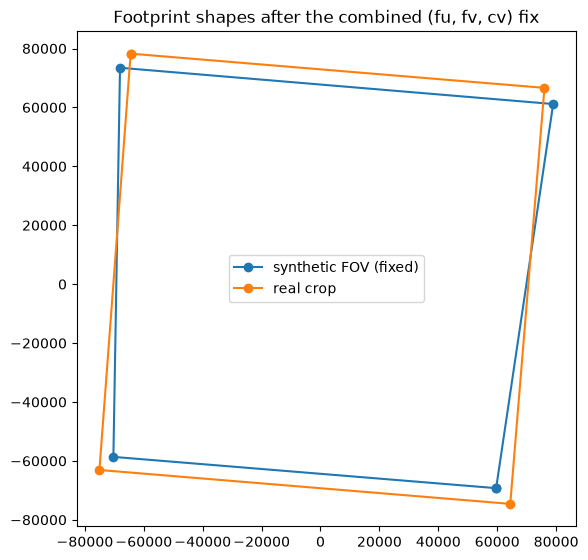

In [12]:
new_footprint = camera_module.footprint_lonlat(c_km, r_cam_to_me, fu_new, fv_new, cu, cv_new, session.config.image_size)
new_synthetic_corners = {k: to_local_m(v) for k, v in new_footprint.items() if k != "center" and v}
print("Corner radii from center (m) -- was 100k/100k/117k/117k, real crop is ~98k-101k:")
for name in ["top_left", "top_right", "bottom_left", "bottom_right"]:
    print(f"  {name}: {np.hypot(*new_synthetic_corners[name]):.0f} m")

fig, ax = plt.subplots(figsize=(6, 6))
for corners, label, color in [
    (new_synthetic_corners, "synthetic FOV (fixed)", "tab:blue"),
    (crop_corners, "real crop", "tab:orange"),
]:
    pts = _polygon_order(corners) + [_polygon_order(corners)[0]]
    xs, ys = zip(*pts, strict=True)
    ax.plot(xs, ys, "o-", label=label, color=color)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Footprint shapes after the combined (fu, fv, cv) fix")
fig.tight_layout()

In [13]:
fixed_tsai_path = entry.per_image_config.output_dir / "camera_frame94_fovfix.tsai"
camera_module.write_tsai(
    fixed_tsai_path, np.array(entry.camera.camera_center_moon_me_m), r_cam_to_me, fu_new, fv_new, cu, cv_new
)
fixed_camera = dataclasses.replace(entry.camera, tsai_path=fixed_tsai_path, footprint_lonlat_deg=new_footprint)
fixed_render = render.run_sat_sim(fixed_camera, reproject_dem_ortho, entry.per_image_config)
print("FOV-fixed reproject render:", fixed_render.rendered_tif)

FOV-fixed reproject render: /workspace/output/trn_dataset/_work/M1327210646CE/render/run-camera_frame94_fovfix.tif


In [14]:
fixed_data = plotting.read_raster_band(fixed_render.rendered_tif)
fixed_valid = plotting.valid_pixel_mask(fixed_data)
print(f"Valid pixels: {fixed_valid.mean():.1%} (was {valid.mean():.1%})")

fixed_ring_mask = np.zeros_like(fixed_valid)
fixed_ring_mask[:edge_px, :] = fixed_ring_mask[-edge_px:, :] = True
fixed_ring_mask[:, :edge_px] = fixed_ring_mask[:, -edge_px:] = True
print(
    f"Valid pixels in the outer ~5% edge ring: {fixed_valid[fixed_ring_mask].mean():.1%} (was {valid[ring_mask].mean():.1%})"
)

for name, sl in [
    ("top-left", (slice(0, corner), slice(0, corner))),
    ("top-right", (slice(0, corner), slice(-corner, None))),
    ("bottom-left", (slice(-corner, None), slice(0, corner))),
    ("bottom-right", (slice(-corner, None), slice(-corner, None))),
]:
    print(f"  {name} corner valid: {fixed_valid[sl].mean():.1%}")

Valid pixels: 100.0% (was 100.0%)
Valid pixels in the outer ~5% edge ring: 100.0% (was 100.0%)
  top-left corner valid: 100.0%
  top-right corner valid: 100.0%
  bottom-left corner valid: 100.0%
  bottom-right corner valid: 100.0%


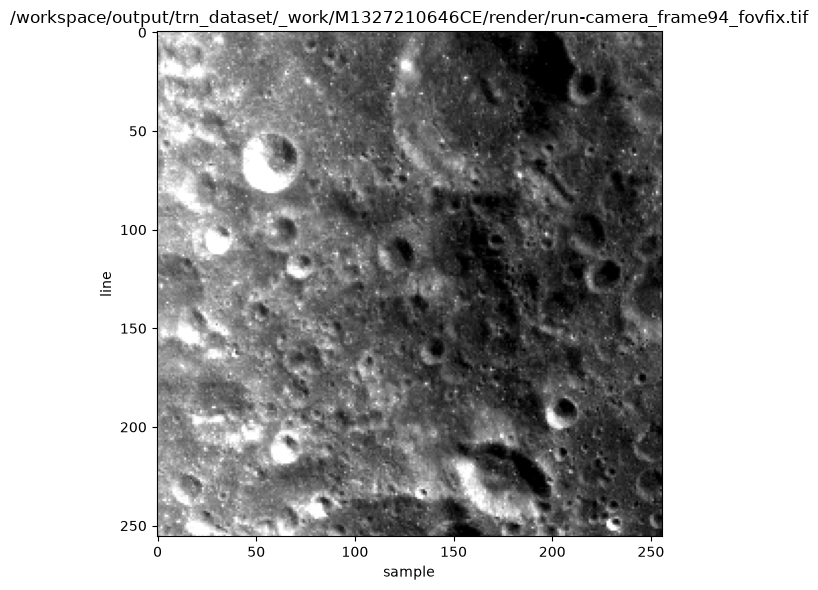

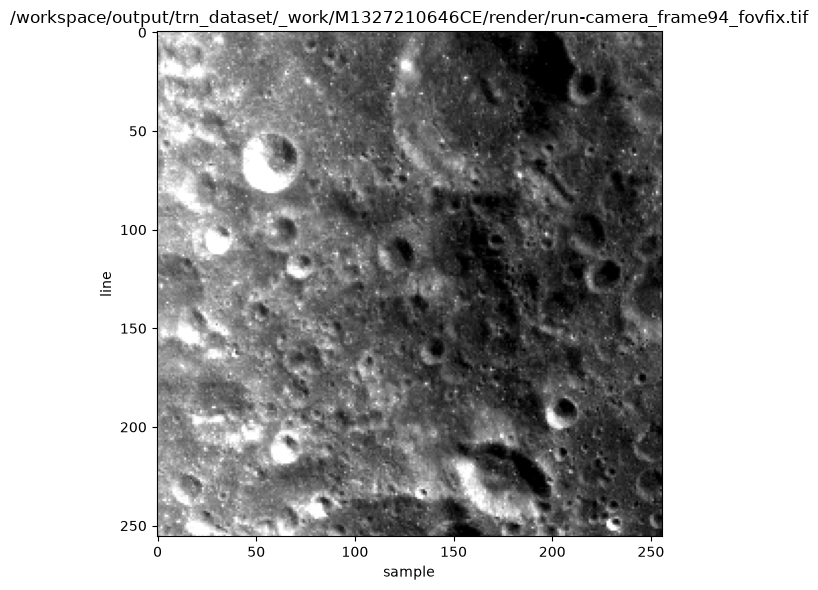

In [15]:
plotting.plot_raster(fixed_render.rendered_tif, cmap="gray")

For comparison, the original (uncorrected) reproject render and `hillshade`'s own render through
the same camera:

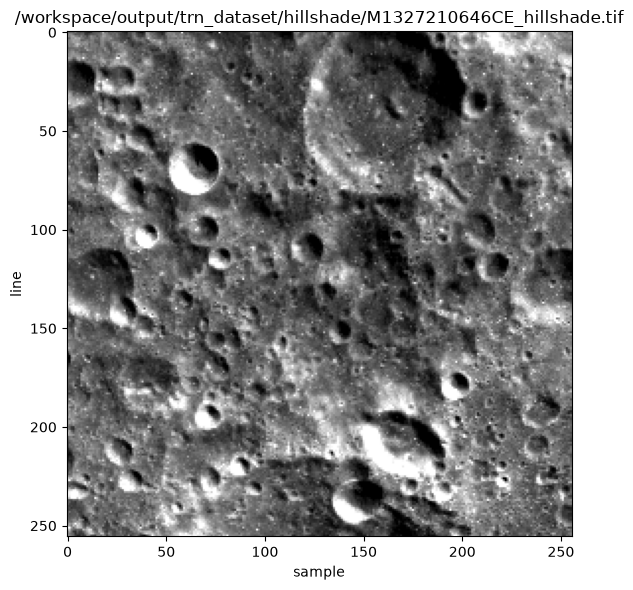

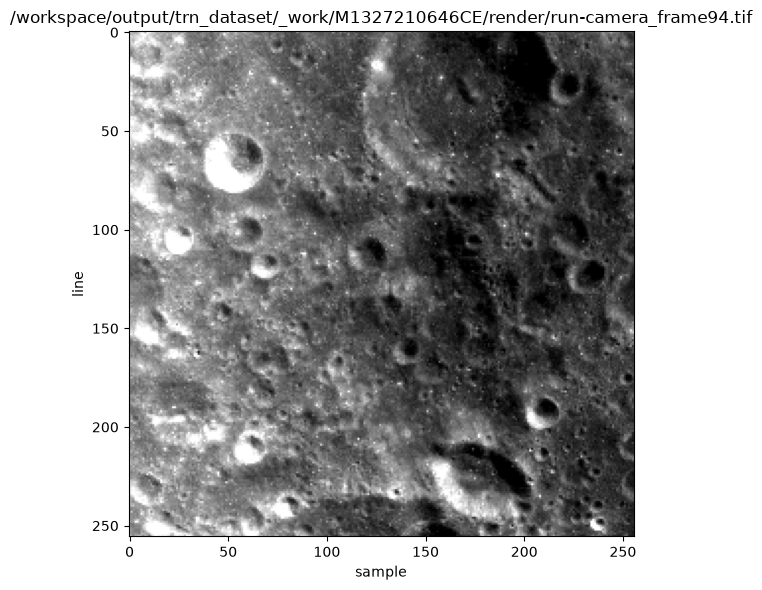

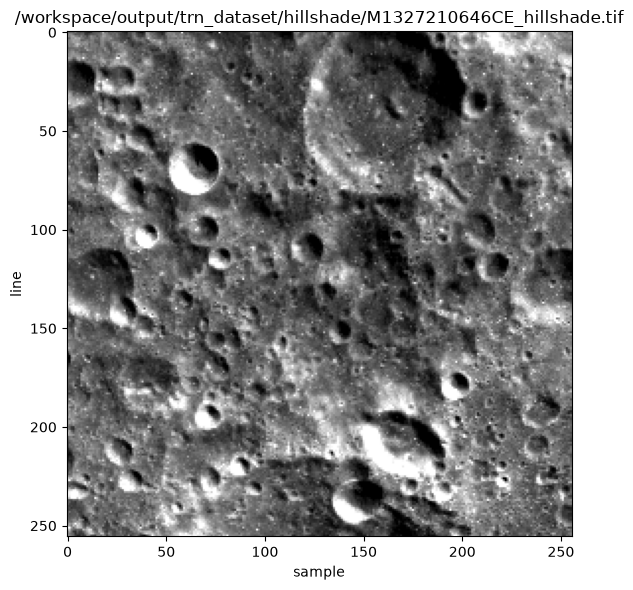

In [16]:
plotting.plot_raster(reproject_render.rendered_tif, cmap="gray")
plotting.plot_raster(entry.hillshade.raster_path, cmap="gray")

## Validating the fix across more images

`FU_SCALE=0.93`/`AT_MARGIN=0.93` above were tuned on `M1327210646CE` alone -- the real open
question from `docs/reproject-fov-investigation.md`: do those same two constants also close the
gap on other real candidates with their own different off-nadir geometry, or does the solve need
retuning per image? (`fv`/`cv` are already solved fresh per image, against that image's own real
`crop_footprint` -- only `FU_SCALE`/`AT_MARGIN` are fixed constants being tested for generality
here.) Three more manifest rows already have `crop`+`hillshade` populated -- the same accidental
`populate(limit=1)` advance documented above, now reused rather than wasted -- spanning a wide
geometry range: `M1327211014CE` (28.7 deg sun elevation, 55.4N), `M1327211334CE` (15.8 deg sun
elevation, 70.7N), `M1327215525CE` (19.4 deg sun elevation, -67.5S).

In [17]:
def evaluate_reproject_coverage(entry, *, fu_scale: float, at_margin: float) -> dict:
    """Run one entry's crop -> reproject -> render -> coverage pipeline, applying the same FOV fix
    as the cells above (`fu_scale=1.0, at_margin=1.0` reproduces the *uncorrected* baseline: `fv`/
    `cv` solved against the real crop footprint with no shrink, `fu` untouched). Returns overall/
    edge-ring/worst-corner valid-pixel fractions."""
    wac_ortho_path = isis_wac.run_cam2map_for_crop(entry.crop_result, entry.dem_ortho_result, entry.per_image_config)
    dem_ortho = lunaserv.result_from_files(wac_ortho_path, entry.dem_ortho_result.dem)

    c_km = np.array(entry.camera.camera_center_moon_me_m) / 1000.0
    r_cam_to_me = np.array(entry.camera.r_cam_to_me)
    cu = session.config.image_size / 2.0
    boresight_ground_km = camera_module.boresight_ground_point_km(c_km, r_cam_to_me)
    along_track_axis_me = np.array(entry.camera.camera_along_track_direction_moon_me)
    cross_track_axis_me = r_cam_to_me[:, 0]

    def decompose(ground_km: np.ndarray) -> tuple[float, float]:
        rel = ground_km - boresight_ground_km
        return float(np.dot(rel, cross_track_axis_me)), float(np.dot(rel, along_track_axis_me))

    crop_at_km = {}
    for name, lonlat in entry.crop_footprint.items():
        if name == "center" or lonlat is None:
            continue
        lon, lat = lonlat
        ground_km = np.array(spice.latrec(MOON_RADIUS_KM, np.radians(lon), np.radians(lat)))
        _, crop_at_km[name] = decompose(ground_km)
    target_near_km = -np.mean([v for v in crop_at_km.values() if v < 0])
    target_far_km = np.mean([v for v in crop_at_km.values() if v >= 0])

    def corner_ground_km(half_angle_u: float, half_angle_v: float, sign_u: float, sign_v: float) -> np.ndarray:
        direction_cam = np.array([sign_u * np.tan(half_angle_u), sign_v * np.tan(half_angle_v), 1.0])
        direction_cam = direction_cam / np.linalg.norm(direction_cam)
        direction_me = r_cam_to_me @ direction_cam
        t = camera_module.ray_sphere_intersect_range(c_km, direction_me)
        assert t is not None, "corner FOV ray does not intersect the Moon"
        return c_km + t * direction_me

    def solve_half_angle_v(half_angle_u: float, target_km: float, sign_v: float, hi: float = np.radians(45.0)) -> float:
        lo = 1e-4
        for _ in range(60):
            mid = (lo + hi) / 2.0
            _, at = decompose(corner_ground_km(half_angle_u, mid, 1.0, sign_v))
            magnitude = sign_v * at
            lo, hi = (mid, hi) if magnitude < target_km else (lo, mid)
        return (lo + hi) / 2.0

    original_half_angle_rad = np.radians(session.config.wac_vis_color_fov_deg / 2.0)
    half_angle_u = original_half_angle_rad * fu_scale
    fu = cu / np.tan(half_angle_u)
    near_half_angle_rad = solve_half_angle_v(half_angle_u, target_near_km * at_margin, sign_v=-1.0)
    far_half_angle_rad = solve_half_angle_v(half_angle_u, target_far_km * at_margin, sign_v=1.0)
    fv = session.config.image_size / (np.tan(near_half_angle_rad) + np.tan(far_half_angle_rad))
    cv = fv * np.tan(near_half_angle_rad)

    footprint = camera_module.footprint_lonlat(c_km, r_cam_to_me, fu, fv, cu, cv, session.config.image_size)
    tsai_path = (
        entry.per_image_config.output_dir / f"camera_{entry.product_id}_scale{fu_scale:.2f}_{at_margin:.2f}.tsai"
    )
    camera_module.write_tsai(tsai_path, np.array(entry.camera.camera_center_moon_me_m), r_cam_to_me, fu, fv, cu, cv)
    scaled_camera = dataclasses.replace(entry.camera, tsai_path=tsai_path, footprint_lonlat_deg=footprint)

    rendered = render.run_sat_sim(scaled_camera, dem_ortho, entry.per_image_config)
    data = plotting.read_raster_band(rendered.rendered_tif)
    valid_mask = plotting.valid_pixel_mask(data)

    edge = max(1, data.shape[0] // 20)
    ring = np.zeros_like(valid_mask)
    ring[:edge, :] = ring[-edge:, :] = ring[:, :edge] = ring[:, -edge:] = True

    c = edge * 2
    corner_valid = {
        name: float(valid_mask[sl].mean())
        for name, sl in [
            ("top-left", (slice(0, c), slice(0, c))),
            ("top-right", (slice(0, c), slice(-c, None))),
            ("bottom-left", (slice(-c, None), slice(0, c))),
            ("bottom-right", (slice(-c, None), slice(-c, None))),
        ]
    }
    return {
        "overall_valid": float(valid_mask.mean()),
        "edge_ring_valid": float(valid_mask[ring].mean()),
        "worst_corner_valid": min(corner_valid.values()),
        "corner_valid": corner_valid,
    }

In [18]:
validation_entries = [dataset[i] for i in range(4)]
validation_results = []
for val_entry in validation_entries:
    baseline = evaluate_reproject_coverage(val_entry, fu_scale=1.0, at_margin=1.0)
    fixed = evaluate_reproject_coverage(val_entry, fu_scale=FU_SCALE, at_margin=AT_MARGIN)
    validation_results.append({"product_id": val_entry.product_id, "baseline": baseline, "fixed": fixed})
    print(f"{val_entry.product_id}:")
    print(f"  baseline: overall={baseline['overall_valid']:.1%}  worst corner={baseline['worst_corner_valid']:.1%}")
    print(f"  fixed:    overall={fixed['overall_valid']:.1%}  worst corner={fixed['worst_corner_valid']:.1%}")

M1327210646CE:
  baseline: overall=99.2%  worst corner=77.6%
  fixed:    overall=100.0%  worst corner=100.0%


ROI center (lon,lat deg): (np.float64(171.92947682091), np.float64(55.719720074809004)), bbox (local m): (-125613.00761846386, -125950.58426552112, 126303.16757085333, 129616.1860057998)
ROI size 2519x2556 px (~100.0 m/px)


M1327211014CE:
  baseline: overall=98.9%  worst corner=70.8%
  fixed:    overall=100.0%  worst corner=100.0%


ROI center (lon,lat deg): (np.float64(177.09922956465), np.float64(70.943965918917)), bbox (local m): (-133091.60935573318, -134377.65139373808, 133547.73819027308, 137403.23372234876)
ROI size 2666x2718 px (~100.0 m/px)


M1327211334CE:
  baseline: overall=97.8%  worst corner=58.2%
  fixed:    overall=100.0%  worst corner=99.8%


ROI center (lon,lat deg): (np.float64(157.16119087074003), np.float64(-67.37700482352498)), bbox (local m): (-78346.82000181294, -78910.31209585893, 79437.26252344865, 80789.61731130196)
ROI size 1578x1597 px (~100.0 m/px)


M1327215525CE:
  baseline: overall=95.5%  worst corner=57.8%
  fixed:    overall=100.0%  worst corner=100.0%


Summary table -- does the one image's tuned `(FU_SCALE, AT_MARGIN)` generalize?

In [19]:
summary = pd.DataFrame(
    [
        {
            "product_id": r["product_id"],
            "baseline_overall": r["baseline"]["overall_valid"],
            "baseline_worst_corner": r["baseline"]["worst_corner_valid"],
            "fixed_overall": r["fixed"]["overall_valid"],
            "fixed_worst_corner": r["fixed"]["worst_corner_valid"],
        }
        for r in validation_results
    ]
)
summary

,product_id,baseline_overall,baseline_worst_corner,fixed_overall,fixed_worst_corner
0,M1327210646CE,0.992386,0.776042,0.999985,1.000000
1,M1327211014CE,0.989243,0.708333,1.000000,1.000000
2,M1327211334CE,0.978165,0.581597,0.999985,0.998264
3,M1327215525CE,0.954605,0.578125,1.000000,1.000000
